Ensemble Learning 

Stacking Ensemble


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Define feature columns and target column based on available data
feature_columns = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']  # Features to predict AQI Value
target_column = 'AQI Value'  # Target column

# Ensure the columns exist
if not all(col in data.columns for col in feature_columns + [target_column]):
    print("One or more specified columns are not in the dataset.")
    print("Columns in dataset:", data.columns)
else:
    X = data[feature_columns]  # Independent variables
    y = data[target_column]  # Dependent variable (target)

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Scale the features (important for some algorithms)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define base regressors for stacking
    base_regressors = [
        ('decision_tree', DecisionTreeRegressor(random_state=42)),
        ('random_forest', RandomForestRegressor(random_state=42)),
        ('svm', SVR(kernel='linear'))  # Support Vector Regressor for regression tasks
    ]

    # Define the meta-regressor
    meta_regressor = RandomForestRegressor(random_state=42)

    # Create the stacking regressor
    stacking_regressor = StackingRegressor(estimators=base_regressors, final_estimator=meta_regressor)

    # Train the stacking regressor
    stacking_regressor.fit(X_train, y_train)

    # Predict on test set
    y_pred = stacking_regressor.predict(X_test)

    # Evaluate the model using relevant metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Stacking Regressor Performance:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")

Stacking Regressor Performance:
Mean Squared Error: 2.6159
R^2 Score: 0.9984


Ada Boost

c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier Performance:
Accuracy: 0.5191

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.99      0.64      2136
           1       0.00      0.00      0.00      2326
           2       0.88      0.94      0.91       251
           3       0.00      0.00      0.00        38
           4       0.89      0.95      0.92       244
           5       0.74      1.00      0.85        14

    accuracy                           0.52      5009
   macro avg       0.50      0.65      0.55      5009
weighted avg       0.29      0.52      0.37      5009



c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


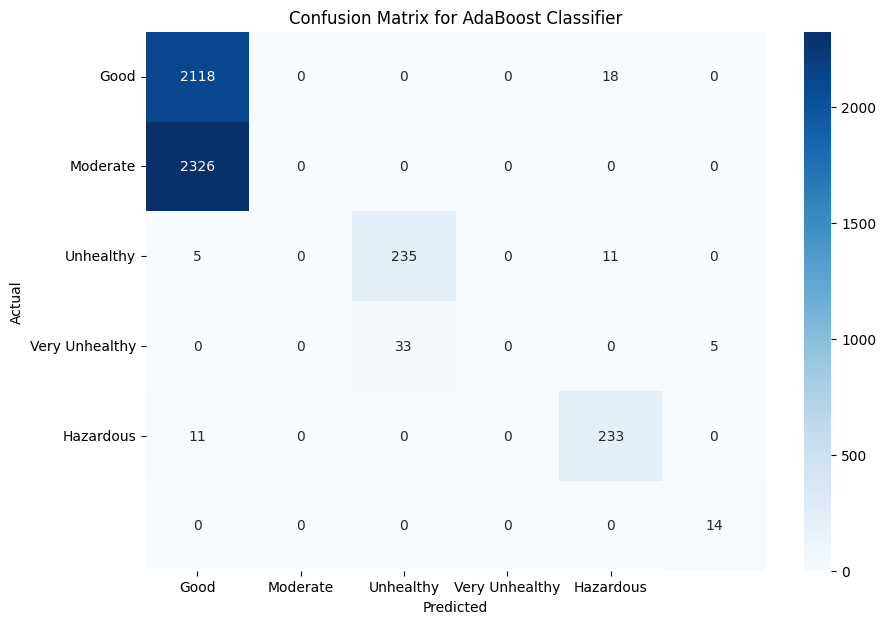

c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hitarth\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hitarth\AppData\Local\

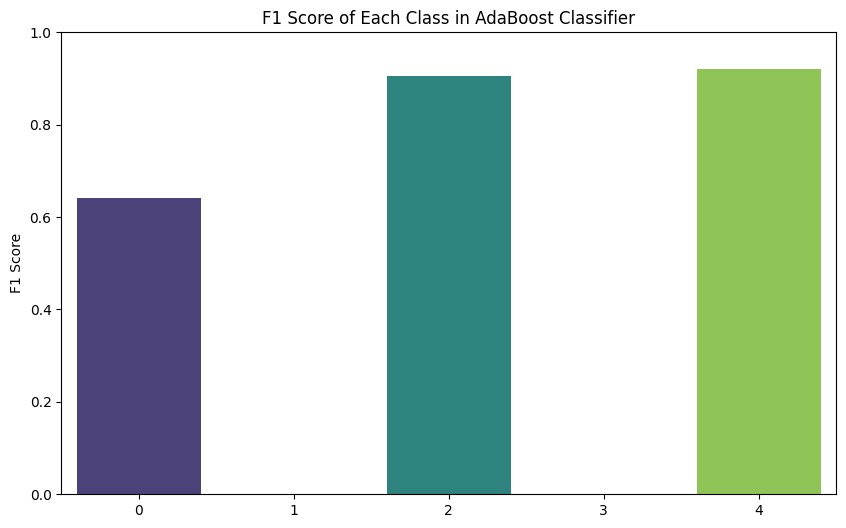

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Define feature columns and target column based on available data
feature_columns = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']  # Features to predict AQI Category
target_column = 'AQI Category'  # Target column

# Ensure the columns exist
if not all(col in data.columns for col in feature_columns + [target_column]):
    print("One or more specified columns are not in the dataset.")
    print("Columns in dataset:", data.columns)
else:
    X = data[feature_columns]  # Independent variables
    y = data[target_column]  # Dependent variable (target)

    # Convert the target column to a classification problem
    y = pd.factorize(y)[0]  # Convert categories to numerical values

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Scale the features (important for some algorithms)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Initialize the base classifier (stump)
    base_classifier = DecisionTreeClassifier(max_depth=1)  # A decision stump

    # Initialize the AdaBoost classifier with the base classifier
    ada_boost_classifier = AdaBoostClassifier(estimator=base_classifier, n_estimators=50, random_state=42)

    # Train the AdaBoost classifier
    ada_boost_classifier.fit(X_train, y_train)

    # Predict on test set
    y_pred = ada_boost_classifier.predict(X_test)

    # Evaluate the model using relevant metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print("AdaBoost Classifier Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Print classification report and confusion matrix
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix Visualization
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous'],
                yticklabels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix for AdaBoost Classifier')
    plt.show()

# Visualizing Performance Metrics: Accuracy, Precision, Recall, F1 Score

# Extracting metrics from classification report for visualization
report = classification_report(y_test, y_pred, output_dict=True)
metrics_names = list(report.keys())[:-3]  # Exclude last three rows (average / macro / weighted)
metrics_values = [report[name]['f1-score'] for name in metrics_names]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_names[:-1], y=metrics_values[:-1], palette='viridis')  # Exclude average scores from bar plot
plt.ylabel('F1 Score')
plt.title('F1 Score of Each Class in AdaBoost Classifier')
plt.ylim(0, 1)  # Set limit for better visualization

plt.show()

Voting Ensemble

Voting Classifier Performance:
Accuracy: 0.9900

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2136
           1       1.00      0.99      1.00      2326
           2       0.92      1.00      0.96       251
           3       0.95      0.95      0.95        38
           4       1.00      0.90      0.95       244
           5       1.00      0.86      0.92        14

    accuracy                           0.99      5009
   macro avg       0.98      0.95      0.96      5009
weighted avg       0.99      0.99      0.99      5009



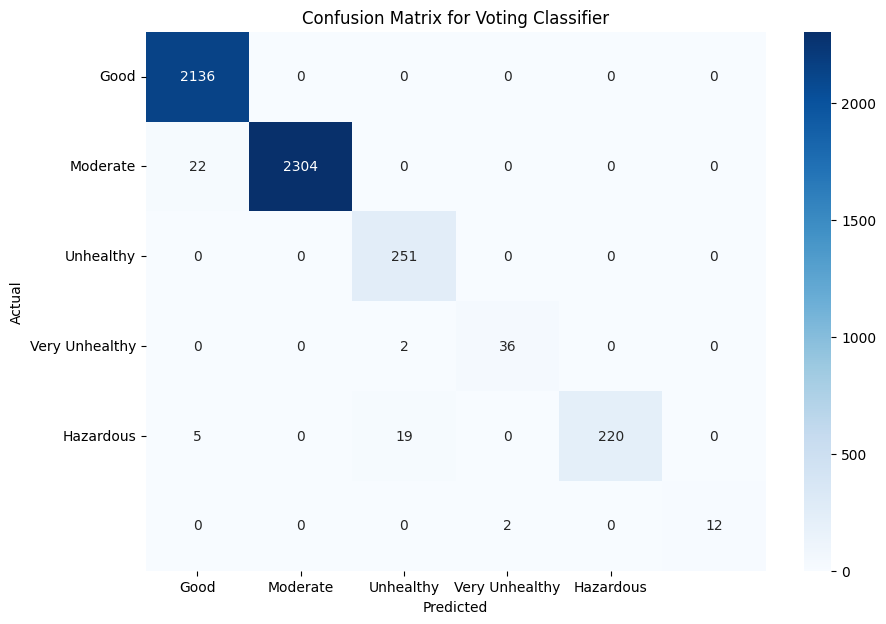

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Define feature columns and target column based on available data
feature_columns = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']  # Features to predict AQI Category
target_column = 'AQI Category'  # Target column

# Ensure the columns exist
if not all(col in data.columns for col in feature_columns + [target_column]):
    print("One or more specified columns are not in the dataset.")
    print("Columns in dataset:", data.columns)
else:
    X = data[feature_columns]  # Independent variables
    y = data[target_column]  # Dependent variable (target)

    # Convert the target column to a classification problem
    y = pd.factorize(y)[0]  # Convert categories to numerical values

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Scale the features (important for some algorithms)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Initialize base classifiers for voting ensemble
    clf1 = DecisionTreeClassifier(random_state=42)
    clf2 = RandomForestClassifier(random_state=42)
    clf3 = GaussianNB()
    clf4 = SVC(probability=True, random_state=42)  # SVC needs probability=True for soft voting

    # Create a voting classifier with hard voting (majority voting)
    voting_clf = VotingClassifier(estimators=[
        ('dt', clf1),
        ('rf', clf2),
        ('gnb', clf3),
        ('svc', clf4)],
        voting='hard')  # Use 'soft' for probability-based voting

    # Train the voting classifier
    voting_clf.fit(X_train, y_train)

    # Predict on test set
    y_pred = voting_clf.predict(X_test)

    # Evaluate the model using relevant metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print("Voting Classifier Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Print classification report and confusion matrix
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous'],
                yticklabels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix for Voting Classifier')
    plt.show()